# A08 — Interference and Phase Kickback

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook; every amplitude here is one you could add up on paper.

---

## The one-sentence version

When a quantum process can reach the same answer by more than one route, you add
the routes' **amplitudes** — arrows in the complex plane, laid head to tail — and
only *then* square the length of what's left.

Two arrows pointing the same way make a long arrow: that outcome becomes likely.
Two arrows pointing opposite ways cancel to nothing: that outcome becomes
**impossible**, even though each route on its own was perfectly possible.

That second sentence has no classical analogue. Probabilities are non-negative,
so classical alternatives can only ever pile up. Amplitudes can cancel, and
*every* quantum algorithm in this repo is a machine for arranging the cancellation
to land on the wrong answers.

## The picture to keep

Think of a walker choosing between two corridors that rejoin at the far end. In
the classical world you add probabilities: $P = P_{\text{left}} + P_{\text{right}}$,
and more routes always means more ways to arrive. In the quantum world you add
amplitudes first,

$$a = a_{\text{left}} + a_{\text{right}}, \qquad P = |a|^2
= |a_{\text{left}}|^2 + |a_{\text{right}}|^2
+ 2\,\mathrm{Re}\!\left(a_{\text{left}}^{*}a_{\text{right}}\right),$$

and that last term — the **interference term** — is the whole story. It is
positive when the arrows agree, negative when they disagree, and zero only when
they are perpendicular. Nothing else in this notebook is harder than that
formula.

## What this notebook builds

1. The **two-path interferometer** (Hadamard, phase, Hadamard) derived by hand,
   with its two paths drawn head-to-tail as arrows in $\mathbb{C}$.
2. The **interference waterfall** — sweep the phase and watch fringes appear
   across a whole register at once.
3. **Phase kickback** from first principles: a controlled-$U$ acting on an
   eigenstate of $U$ leaves the target untouched and writes the eigenvalue's
   phase onto the *control*. This is the engine of A09, A10 and A11.
4. Where it all breaks: interference needs **coherence**, and we watch the
   fringes die under dephasing.

In [1]:
from qviz import backends, bloch, grid, style

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A08")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

seed: 20260812


## The toolkit, rebuilt

Everything below is the same little-endian machinery A05 and A06 established:
**qubit 0 is the rightmost character** of a bitstring, so index $i$ has qubit
$q$'s bit equal to `(i >> q) & 1`, and placing a single-qubit operator on qubit
$k$ means the Kronecker factors run from the highest qubit index *down* to zero.

Nothing here is imported from a helper. `qviz` draws; it never computes.

In [2]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

P0 = np.array([[1, 0], [0, 0]], dtype=complex)      # |0><0|
P1 = np.array([[0, 0], [0, 1]], dtype=complex)      # |1><1|

KET0 = np.array([1, 0], dtype=complex)
KET1 = np.array([0, 1], dtype=complex)
PLUS = np.array([1, 1], dtype=complex) / np.sqrt(2)
MINUS = np.array([1, -1], dtype=complex) / np.sqrt(2)


def phase_gate(theta):
    """P(theta) = diag(1, exp(i theta)) - a relative phase, nothing else."""
    return np.diag([1.0, np.exp(1j * theta)]).astype(complex)


def op_on(U, k, n):
    """Place the single-qubit operator U on qubit k of an n-qubit register.

    Little-endian: qubit 0 is the RIGHTMOST label character, hence the LAST
    Kronecker factor, hence the loop counts down from n-1.
    """
    out = np.array([[1.0 + 0j]])
    for j in range(n - 1, -1, -1):
        out = np.kron(out, U if j == k else I2)
    return out


def controlled(U, control, target, n):
    """|0><0|_c (x) I  +  |1><1|_c (x) U_t, for any pair of qubits."""
    if control == target:
        raise ValueError("control and target must be different qubits")
    return op_on(P0, control, n) + op_on(P1, control, n) @ op_on(U, target, n)


def label(i, n):
    """Printed bitstring: qubit n-1 leftmost, qubit 0 rightmost."""
    return format(i, f"0{n}b")


def probabilities(state):
    """Born rule."""
    return np.abs(np.asarray(state)) ** 2


# Sanity: X on qubit 0 of |00> must land on index 1, printed |01>.
v = np.zeros(4, dtype=complex)
v[0] = 1.0
print("X on qubit 0 of |00> ->  index",
      int(np.argmax(np.abs(op_on(X, 0, 2) @ v))), " = |01>")

X on qubit 0 of |00> ->  index 1  = |01>


## The two-path interferometer, by hand

Here is the smallest machine that interferes. Start in $|0\rangle$ and apply

$$H \;\to\; P(\varphi) \;\to\; H, \qquad P(\varphi)=\mathrm{diag}(1, e^{i\varphi}).$$

The first Hadamard splits the walker into two corridors, the phase gate delays
one of them, and the second Hadamard recombines. In optics this is a
**Mach–Zehnder interferometer**; in atomic physics the same sequence is a
**Ramsey experiment**; on a chip it is three lines of code.

Now do the bookkeeping *without* multiplying the matrices, because the point is
to see the routes. There are exactly two paths from input $|0\rangle$ to output
$|k\rangle$: one through the intermediate state $|0\rangle$, one through
$|1\rangle$. Each path's amplitude is the product of the three factors it picks
up along the way,

$$a_k^{(j)} \;=\; \underbrace{H_{j0}}_{\text{split}}\;\cdot\;
\underbrace{e^{i\varphi j}}_{\text{delay}}\;\cdot\;
\underbrace{H_{kj}}_{\text{recombine}}, \qquad j \in \{0, 1\},$$

and the amplitude of outcome $k$ is the **sum over paths** $a_k = a_k^{(0)} + a_k^{(1)}$.
Multiplying it out:

$$a_0 = \tfrac{1}{2}\left(1 + e^{i\varphi}\right), \qquad
a_1 = \tfrac{1}{2}\left(1 - e^{i\varphi}\right),$$

$$P(0) = \cos^2\tfrac{\varphi}{2}, \qquad P(1) = \sin^2\tfrac{\varphi}{2}.$$

At $\varphi = 0$ the walker leaves through door 0 with certainty. At
$\varphi = \pi$ it leaves through door 1 with certainty — a *phase* the walker
picked up in one corridor has completely rerouted it. And note that a classical
coin-flipping walker would come out 50/50 for *any* $\varphi$: the phase would be
invisible, because there would be nothing to add it to.

In [3]:
def path_amplitudes(k, phi):
    """The two path amplitudes reaching outcome k, as complex numbers.

    Path j: split into |j> (factor H[j,0]), pick up exp(i*phi) if j == 1,
    recombine into |k> (factor H[k,j]). No matrix product anywhere - this is
    the sum-over-paths written out.
    """
    return np.array([H[j, 0] * np.exp(1j * phi * j) * H[k, j] for j in (0, 1)])


def interferometer(phi):
    """The same thing as a matrix product, for cross-checking."""
    return H @ phase_gate(phi) @ H @ KET0


print(f"{'phi/pi':>7} {'path 0':>18} {'path 1':>18} {'sum':>18} {'P(0)':>8}")
for phi in [0.0, np.pi / 3, np.pi / 2, 2 * np.pi / 3, np.pi]:
    p = path_amplitudes(0, phi)
    s = p.sum()
    print(f"{phi/np.pi:7.3f} {p[0]:>18.4f} {p[1]:>18.4f} {s:>18.4f} "
          f"{abs(s)**2:8.4f}")

# The sum over paths must reproduce the matrix product, and cos^2(phi/2).
for phi in rng.uniform(0, 2 * np.pi, 5):
    direct = interferometer(phi)
    summed = np.array([path_amplitudes(k, phi).sum() for k in (0, 1)])
    assert np.allclose(direct, summed)
    assert np.isclose(abs(summed[0]) ** 2, np.cos(phi / 2) ** 2)
print("\nsum-over-paths == matrix product == cos^2(phi/2).  All three agree.")

 phi/pi             path 0             path 1                sum     P(0)
  0.000     0.5000+0.0000j     0.5000+0.0000j     1.0000+0.0000j   1.0000
  0.333     0.5000+0.0000j     0.2500+0.4330j     0.7500+0.4330j   0.7500
  0.500     0.5000+0.0000j     0.0000+0.5000j     0.5000+0.5000j   0.5000
  0.667     0.5000+0.0000j    -0.2500+0.4330j     0.2500+0.4330j   0.2500
  1.000     0.5000+0.0000j    -0.5000+0.0000j     0.0000+0.0000j   0.0000

sum-over-paths == matrix product == cos^2(phi/2).  All three agree.


## Figure 1 — amplitudes added head to tail

This is the picture the whole notebook rests on. Each panel is the complex plane.
The **blue arrow** is the path through $|0\rangle$, drawn from the origin. The
**orange arrow** is the path through $|1\rangle$, drawn *starting where the blue
one ended* — that is what "adding complex numbers" means geometrically. The
dashed grey arrow from the origin to the final tip is the resulting amplitude,
and its length squared is the probability printed across the top of each panel.

The top row is outcome $|0\rangle$, the bottom row is outcome $|1\rangle$. Read
across: as $\varphi$ turns the orange arrow, the top resultant shrinks and the
bottom one grows, and they trade probability perfectly.

The two extreme columns are the ones to memorise. At $\varphi = 0$: the arrows
agree on top (**constructive**) and cancel exactly on the bottom
(**destructive**). At $\varphi = \pi$ they have swapped roles.

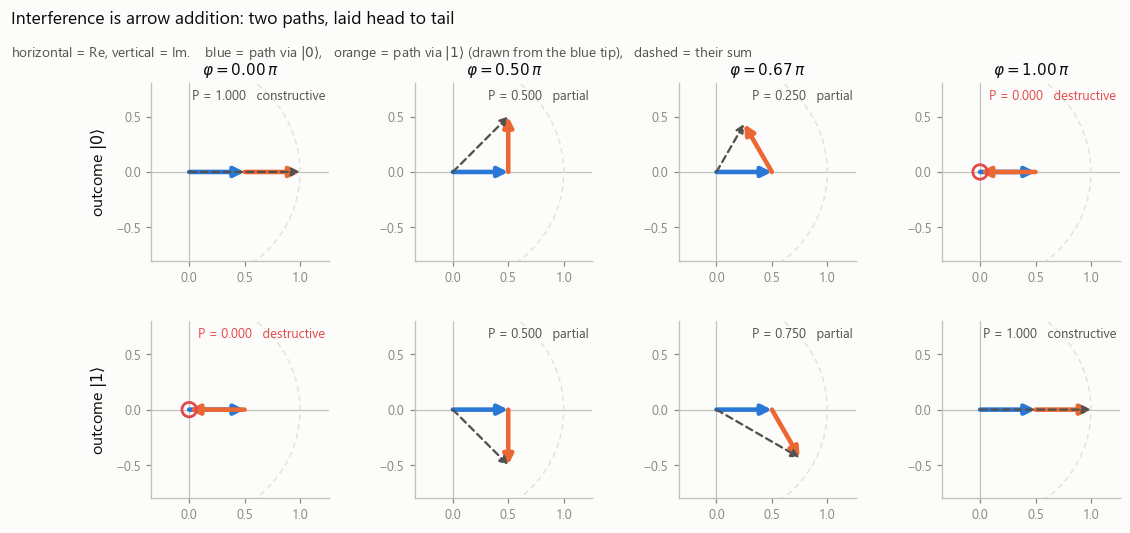

phi = 0.00 pi   P(0) = 1.0000   P(1) = 0.0000   (sum 1.0000)
phi = 0.50 pi   P(0) = 0.5000   P(1) = 0.5000   (sum 1.0000)
phi = 0.67 pi   P(0) = 0.2500   P(1) = 0.7500   (sum 1.0000)
phi = 1.00 pi   P(0) = 0.0000   P(1) = 1.0000   (sum 1.0000)


In [4]:
PHIS = [0.0, np.pi / 2, 2 * np.pi / 3, np.pi]

fig, axes = plt.subplots(2, len(PHIS), figsize=(10.4, 4.9), layout="none")
fig.subplots_adjust(top=0.845, bottom=0.075, left=0.105, right=0.995,
                    hspace=0.34, wspace=0.16)

for col, phi in enumerate(PHIS):
    for row, k in enumerate((0, 1)):
        ax = axes[row, col]
        a = path_amplitudes(k, phi)
        total = a.sum()

        ax.axhline(0, color=style.AXIS, lw=0.8, zorder=1)
        ax.axvline(0, color=style.AXIS, lw=0.8, zorder=1)
        ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls=(0, (4, 3)),
                                color=style.GRID, lw=0.9, zorder=1))

        # head-to-tail: path 1 starts where path 0 finished
        starts = [0j, a[0]]
        for amp, start, col_, lab in [(a[0], starts[0], style.BLUE, "path 0"),
                                      (a[1], starts[1], style.ORANGE, "path 1")]:
            ax.annotate("", xy=(start.real + amp.real, start.imag + amp.imag),
                        xytext=(start.real, start.imag), zorder=3,
                        arrowprops=dict(arrowstyle="-|>", color=col_, lw=3.0,
                                        shrinkA=0, shrinkB=0, mutation_scale=13))
        if abs(total) > 1e-9:
            ax.annotate("", xy=(total.real, total.imag), xytext=(0, 0), zorder=4,
                        arrowprops=dict(arrowstyle="-|>", color=style.INK_2,
                                        lw=1.5, ls=(0, (3, 2)), shrinkA=0,
                                        shrinkB=0, mutation_scale=11))
        else:
            ax.scatter([0], [0], s=90, facecolor="none", edgecolor=style.RED,
                       linewidths=1.8, zorder=5)

        p = abs(total) ** 2
        verdict = ("constructive" if p > 0.99 else
                   "destructive" if p < 0.01 else "partial")
        ax.text(0.98, 0.965, f"P = {p:.3f}   {verdict}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8.5,
                color=style.RED if p < 0.01 else style.INK_2)

        # Framed tightly on where the arrows actually go, so the panels are not
        # 70% empty; the dashed unit circle enters as an arc top and bottom.
        ax.set_xlim(-0.34, 1.26)
        ax.set_ylim(-0.80, 0.80)
        ax.set_aspect("equal")
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([-0.5, 0, 0.5])
        ax.grid(False)
        if col == 0:
            ax.set_ylabel("outcome " + grid.ket(str(k)), fontsize=10.5,
                          color=style.INK)
        if row == 0:
            ax.set_title(rf"$\varphi = {phi/np.pi:.2f}\,\pi$", loc="center",
                         fontsize=10, pad=6)

fig.suptitle("Interference is arrow addition: two paths, laid head to tail",
             x=0.004, ha="left", fontsize=11.5)
fig.text(0.004, 0.885, "horizontal = Re, vertical = Im.    blue = path via "
         + grid.ket("0") + ",   orange = path via " + grid.ket("1")
         + " (drawn from the blue tip),   dashed = their sum",
         fontsize=9, color=style.INK_2, va="bottom")
plt.show()

for phi in PHIS:
    a0, a1 = path_amplitudes(0, phi).sum(), path_amplitudes(1, phi).sum()
    print(f"phi = {phi/np.pi:.2f} pi   P(0) = {abs(a0)**2:.4f}   "
          f"P(1) = {abs(a1)**2:.4f}   (sum {abs(a0)**2 + abs(a1)**2:.4f})")

The red circle in the bottom-left panel is the moment worth staring at. Two
routes, each individually carrying amplitude $\tfrac12$ — so each individually
"wants" to deliver probability $\tfrac14$ — and the outcome is **exactly zero**.
Adding a way to arrive made arriving impossible.

That is the resource. A quantum algorithm spends its gates arranging for the
wrong answers to sit in that red circle.

## The sign flip that shows nothing, until it does

A01 made the distinction between global and relative phase; here is the payoff.

Take $|+\rangle$ and apply $Z$, which flips the sign of the $|1\rangle$
amplitude, producing $|-\rangle$. Measure. Both give 0 and 1 exactly half the
time — the sign is **invisible**, and no number of shots will ever reveal it.

Now put a Hadamard in front of the measurement. $H|+\rangle = |0\rangle$ and
$H|-\rangle = |1\rangle$: the two states are now perfectly distinguishable, in a
single shot, with certainty.

Nothing about the states changed between those two paragraphs. What changed is
whether we gave the amplitudes a chance to interfere before squaring them. A
relative phase is not directly observable; it is observable *after you interfere
it with something*. Every algorithm here is an elaborate version of that
sentence.

(Contrast with a **global** phase: multiply the whole state by $e^{i\varphi}$ and
no interference experiment, ever, can detect it — the factor comes out of every
path identically and cancels in $|a|^2$. The check below confirms it survives
even a Hadamard.)

In [5]:
minus = Z @ PLUS
print("Z|+> == |->                 :", np.allclose(minus, MINUS))
print("probabilities of |+>        :", np.round(probabilities(PLUS), 6))
print("probabilities of |->        :", np.round(probabilities(minus), 6))
print("  -> a measurement cannot tell them apart.\n")

print("probabilities of H|+>       :", np.round(probabilities(H @ PLUS), 6))
print("probabilities of H|->       :", np.round(probabilities(H @ minus), 6))
print("  -> after interfering, one shot separates them with certainty.\n")

glob = np.exp(1j * 0.7) * PLUS
print("global phase, before H      :", np.round(probabilities(glob), 6))
print("global phase, after H       :", np.round(probabilities(H @ glob), 6))
print("  -> a GLOBAL phase stays invisible no matter what we interfere it with.")

Z|+> == |->                 : True
probabilities of |+>        : [0.5 0.5]
probabilities of |->        : [0.5 0.5]
  -> a measurement cannot tell them apart.

probabilities of H|+>       : [1. 0.]
probabilities of H|->       : [0. 1.]
  -> after interfering, one shot separates them with certainty.

global phase, before H      : [0.5 0.5]
global phase, after H       : [1. 0.]
  -> a GLOBAL phase stays invisible no matter what we interfere it with.


## Figure 2 — sweeping the phase: the fringe

Rather than four snapshots, turn the dial. The top strip is the output state at
eight values of $\varphi$, drawn with the repo's amplitude bars (height =
$|$amplitude$|$, hue = phase, clock hand = the same phase as an angle). Below it,
the probabilities as a continuous curve.

The result is a **fringe**: a smooth $\cos^2$ oscillation, drawn out of a system
whose only moving part is an angle you cannot measure directly. This curve is
what an interferometer *is*, and B20 will measure the same curve on a simulated
device shot by shot.

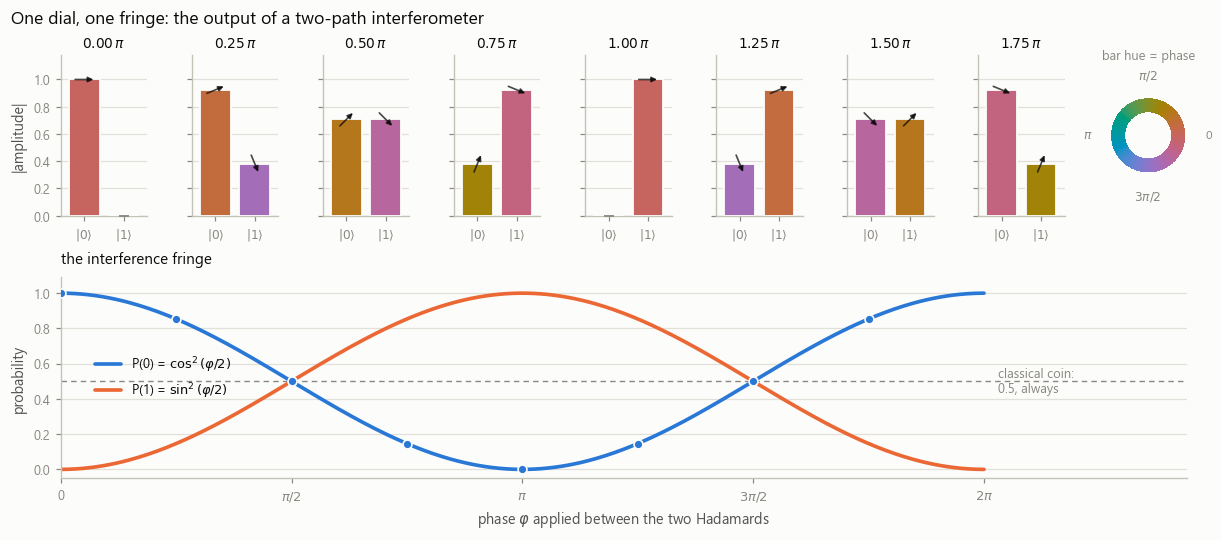

In [6]:
phi_frames = np.linspace(0, 2 * np.pi, 8, endpoint=False)
phi_dense = np.linspace(0, 2 * np.pi, 401)
p_dense = np.array([probabilities(interferometer(p)) for p in phi_dense])

fig = plt.figure(figsize=(11.0, 4.8))
gs = fig.add_gridspec(2, 9, height_ratios=[1.0, 1.25],
                      width_ratios=[1] * 8 + [0.9])

for j, phi in enumerate(phi_frames):
    ax = fig.add_subplot(gs[0, j])
    grid.amp_bars(ax, interferometer(phi), labels=["0", "1"], ylim=1.18)
    ax.set_title(rf"${phi/np.pi:.2f}\,\pi$", loc="center", fontsize=9, pad=5)
    if j:
        ax.set_ylabel("")
        ax.set_yticklabels([])

axw = fig.add_subplot(gs[0, 8], projection="polar")
style.phase_wheel(axw, label="bar hue = phase")

axc = fig.add_subplot(gs[1, :])
axc.plot(phi_dense, p_dense[:, 0], color=style.BLUE, lw=2.4,
         label="P(0) = $\\cos^2(\\varphi/2)$")
axc.plot(phi_dense, p_dense[:, 1], color=style.ORANGE, lw=2.4,
         label="P(1) = $\\sin^2(\\varphi/2)$")
axc.axhline(0.5, color=style.MUTED, lw=0.9, ls=(0, (4, 3)), zorder=1)
axc.scatter(phi_frames, [probabilities(interferometer(p))[0] for p in phi_frames],
            s=34, color=style.BLUE, edgecolor=style.SURFACE, linewidths=1.1,
            zorder=5)
axc.text(2 * np.pi * 1.015, 0.5, "classical coin:\n0.5, always", va="center",
         fontsize=8.5, color=style.MUTED)
axc.set_xlim(0, 2 * np.pi * 1.22)
axc.set_ylim(-0.05, 1.09)
axc.set_xticks(np.linspace(0, 2 * np.pi, 5))
axc.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axc.set_xlabel(r"phase $\varphi$ applied between the two Hadamards")
axc.set_ylabel("probability")
axc.legend(loc="center left", bbox_to_anchor=(0.02, 0.5), ncols=1)
axc.set_title("the interference fringe", loc="left", fontsize=10)

fig.suptitle("One dial, one fringe: the output of a two-path interferometer",
             x=0.004, ha="left", fontsize=11.5)
plt.show()

## Figure 3 — the interference waterfall

Two paths give a $\cos^2$. What happens with **eight**?

Take three qubits, put them all in $|+\rangle$ (so all eight basis states carry
amplitude $1/\sqrt8$), then apply a *phase ramp*: basis state $|k\rangle$ picks up
$e^{ik\varphi}$. That is not an exotic operation — since $k = 4b_2 + 2b_1 + b_0$,
the ramp is just three ordinary phase gates, $P(\varphi)$ on qubit 0,
$P(2\varphi)$ on qubit 1, $P(4\varphi)$ on qubit 2. Then recombine with $H^{\otimes3}$.

Now every output amplitude is a sum of **eight** arrows:

$$a_j = \frac{1}{8}\sum_{k=0}^{7} e^{ik\varphi}\,(-1)^{\,k \cdot j},$$

where $k\cdot j$ is the parity of the bits $k$ and $j$ share. Turning $\varphi$
turns all eight arrows at different rates, and the sums swing violently between
near-total reinforcement and near-total cancellation.

For the $|000\rangle$ output the sign factor is always $+1$, so the sum is a plain
geometric series and collapses to the classic **N-slit diffraction** formula

$$a_{000} = \frac{1}{8}\,\frac{\sin 4\varphi}{\sin(\varphi/2)}\,e^{i\,7\varphi/2},
\qquad P(000) = \left(\frac{\sin 4\varphi}{8\sin(\varphi/2)}\right)^{2}.$$

**Left — the waterfall.** Every probability distribution, stacked: one row per
$\varphi$, $\varphi$ increasing downward, brightness = probability. The fringes
are the vertical stripes, and you can watch them appear as the dial turns.

**Middle — why.** Figure 1's picture, now with eight arrows instead of two,
chained head to tail for the $|000\rangle$ output. At $\varphi = 0$ they lie in a
straight line and the resultant is as long as it can be. As $\varphi$ grows the
chain curls, and at $\varphi = \pi/4$ the eight arrows close into a **complete
circle** — the chain comes back to where it started, and the amplitude is exactly
zero. That closed circle is the whole mechanism of a diffraction null.

**Right — the cut.** The $|000\rangle$ column against the analytic fringe, with
$|001\rangle$ for contrast.

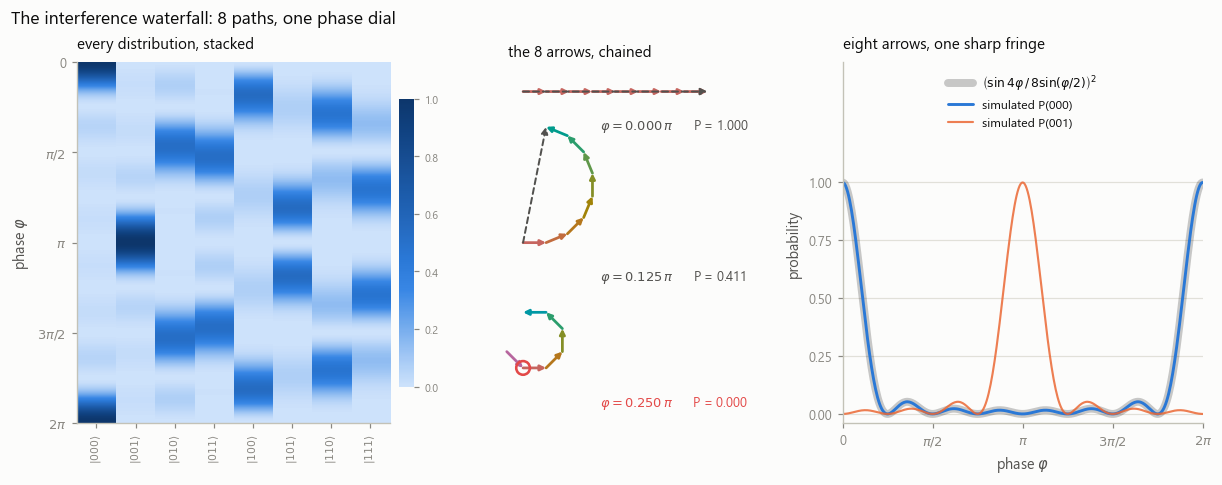

max deviation from the N-slit formula: 1.33e-15
every row sums to 1: True


In [7]:
N_Q = 3
DIM = 2 ** N_Q
H3 = op_on(H, 0, N_Q) @ op_on(H, 1, N_Q) @ op_on(H, 2, N_Q)


def phase_ramp(phi, n=N_Q):
    """exp(i k phi) on basis state k, built from n ordinary phase gates."""
    M = np.eye(2 ** n, dtype=complex)
    for q in range(n):
        M = op_on(phase_gate(phi * 2 ** q), q, n) @ M
    return M


def multipath(phi):
    """H^(x)n  ->  phase ramp  ->  H^(x)n, starting from |0...0>."""
    psi = np.zeros(DIM, dtype=complex)
    psi[0] = 1.0
    return H3 @ phase_ramp(phi) @ H3 @ psi


# The ramp really is exp(i k phi) on the diagonal - no hand-waving.
chk = np.diag(phase_ramp(0.37))
assert np.allclose(chk, np.exp(1j * 0.37 * np.arange(DIM)))

phis = np.linspace(0, 2 * np.pi, 361)
water = np.array([probabilities(multipath(p)) for p in phis])   # (361, 8)

fig = plt.figure(figsize=(11.0, 4.3))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.05, 1.15])

# ---- (a) the heatmap
axh = fig.add_subplot(gs[0, 0])
im = axh.imshow(water, aspect="auto", origin="upper", cmap=style.SEQ,
                vmin=0, vmax=water.max(),
                extent=(-0.5, DIM - 0.5, 2 * np.pi, 0.0),
                interpolation="nearest")
axh.set_xticks(range(DIM))
axh.set_xticklabels([grid.ket(label(i, N_Q)) for i in range(DIM)], rotation=90,
                    fontsize=7)
axh.set_yticks(np.linspace(0, 2 * np.pi, 5))
axh.set_yticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axh.set_ylabel(r"phase $\varphi$")
axh.grid(False)
cb = fig.colorbar(im, ax=axh, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
axh.set_title("every distribution, stacked", loc="left", fontsize=10)

# ---- (b) the eight arrows, chained - Figure 1's picture, scaled up.
# All three chains share ONE axis and therefore one scale, so the resultants are
# directly comparable; they are simply drawn at different vertical offsets.
axa = fig.add_subplot(gs[0, 1])
for phi, yoff in [(0.0, 0.0), (np.pi / 8, -0.82), (np.pi / 4, -1.50)]:
    arrows = np.exp(1j * np.arange(DIM) * phi) / DIM     # the 8 path amplitudes
    pts = np.concatenate([[0j], np.cumsum(arrows)]) + 1j * yoff
    cols = style.phase_colors(arrows)
    for k in range(DIM):
        axa.annotate("", xy=(pts[k + 1].real, pts[k + 1].imag),
                     xytext=(pts[k].real, pts[k].imag), zorder=3,
                     arrowprops=dict(arrowstyle="-|>", color=cols[k], lw=1.8,
                                     shrinkA=0, shrinkB=0, mutation_scale=7))
    end, start = pts[-1], pts[0]
    if abs(end - start) > 1e-9:
        axa.annotate("", xy=(end.real, end.imag),
                     xytext=(start.real, start.imag), zorder=4,
                     arrowprops=dict(arrowstyle="-|>", color=style.INK_2, lw=1.3,
                                     ls=(0, (3, 2)), shrinkA=0, shrinkB=0,
                                     mutation_scale=9))
    else:
        axa.scatter([start.real], [start.imag], s=80, facecolor="none",
                    edgecolor=style.RED, linewidths=1.7, zorder=5)
    p = abs(end - start) ** 2
    axa.text(0.42, yoff - 0.14, rf"$\varphi = {phi/np.pi:.3f}\,\pi$"
             f"      P = {p:.3f}", fontsize=8.5, va="top", ha="left",
             color=style.RED if p < 1e-9 else style.INK_2)
axa.set_xlim(-0.08, 1.05)
axa.set_ylim(-1.80, 0.16)
axa.set_aspect("equal")
axa.axis("off")
axa.set_title("the 8 arrows, chained", loc="left", fontsize=10, pad=4)

# ---- (c) the |000> cut against the analytic fringe
axc = fig.add_subplot(gs[0, 2])
with np.errstate(divide="ignore", invalid="ignore"):
    analytic = np.where(np.abs(np.sin(phis / 2)) < 1e-9, 1.0,
                        (np.sin(4 * phis) / (8 * np.sin(phis / 2))) ** 2)
axc.plot(phis, analytic, color=style.INK, lw=5.2, alpha=0.22,
         label=r"$\left(\sin 4\varphi\,/\,8\sin(\varphi/2)\right)^2$")
axc.plot(phis, water[:, 0], color=style.BLUE, lw=1.9, label="simulated P(000)")
axc.plot(phis, water[:, 1], color=style.ORANGE, lw=1.4, alpha=0.85,
         label="simulated P(001)")
axc.set_xlim(0, 2 * np.pi)
axc.set_ylim(-0.04, 1.52)
axc.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
axc.set_xticks(np.linspace(0, 2 * np.pi, 5))
axc.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axc.set_xlabel(r"phase $\varphi$")
axc.set_ylabel("probability")
axc.legend(loc="upper center", ncols=1, fontsize=8)
axc.set_title("eight arrows, one sharp fringe", loc="left", fontsize=10)

fig.suptitle("The interference waterfall: 8 paths, one phase dial",
             x=0.004, ha="left", fontsize=11.5)
plt.show()

print("max deviation from the N-slit formula:",
      f"{np.max(np.abs(water[:, 0] - analytic)):.2e}")
print("every row sums to 1:", np.allclose(water.sum(axis=1), 1.0))

Three things the waterfall shows that the two-path fringe could not.

**Sharpness.** With two paths the peak is a lazy $\cos^2$, half a period wide.
With eight it is a spike: away from $\varphi = 0$ the eight arrows spread around
the circle and cancel almost perfectly, so probability collapses. More paths
means *sharper* discrimination — the same reason a diffraction grating out-resolves
a double slit, and the same reason phase estimation gets more precise with more
qubits (A11).

**Redistribution, not destruction.** Every row of the heatmap sums to exactly 1.
Interference never destroys probability; it moves it. When $|000\rangle$ goes
dark, the mass has gone somewhere — look along the row and you can see where.

**Structure is basis-dependent.** The bright bands are not random. The columns
have different fringe patterns because the sign factor $(-1)^{k\cdot j}$ is
different for each output, and reading which column lights up at which $\varphi$
is, essentially, phase estimation. We will not spoil A11; just notice that the
information about $\varphi$ is sitting there in plain sight.

## Phase kickback, derived

Now the trick that turns interference into an algorithm.

Take a controlled-$U$, and put the **target** into an eigenstate of $U$:

$$U|u\rangle = e^{i\theta}|u\rangle.$$

Put the control into $|+\rangle$. Then, writing the control on the right (little
endian, so the control is qubit 0):

$$\mathrm{C}U\;\tfrac{1}{\sqrt2}\big(|0\rangle_c + |1\rangle_c\big)|u\rangle_t
= \tfrac{1}{\sqrt2}\big(|0\rangle_c|u\rangle_t + |1\rangle_c\,U|u\rangle_t\big)
= \tfrac{1}{\sqrt2}\big(|0\rangle_c + e^{i\theta}|1\rangle_c\big)|u\rangle_t.$$

Stare at the right-hand side. The target is *exactly where it started* —
$|u\rangle$, unchanged, not even entangled. The eigenvalue's phase has jumped
onto the **control**, which the gate was supposed to be merely reading.

Two reasons this is startling and one reason it isn't:

- Startling 1: nothing "happened" to the control. No gate was applied to it. Yet
  its state changed.
- Startling 2: the target was acted on by a non-trivial unitary and came out
  identical.
- Not startling: $e^{i\theta}$ is a *number*. Numbers commute with everything, so
  the factor produced by $U$ acting on the target slides freely across the tensor
  product and lands next to $|1\rangle_c$. On the target it would have been a
  global phase — invisible. On the control it is a **relative** phase between
  $|0\rangle_c$ and $|1\rangle_c$ — and Figure 2 showed exactly how to read a
  relative phase out with a Hadamard.

Phase kickback is that promotion: a global phase on one subsystem becoming a
relative phase on another. Deutsch–Jozsa (A09), Grover's oracle (A10) and phase
estimation (A11) are all the same move.

We take $U$ with eigenvectors $|+\rangle$ and $|-\rangle$ and eigenvalues
$e^{2\pi i(0.30)}$, $e^{2\pi i(0.75)}$ — deliberately not a textbook gate, so
nothing can be read off by pattern-matching.

In [8]:
THETA_P = 2 * np.pi * 0.30          # eigenvalue phase on |+>
THETA_M = 2 * np.pi * 0.75          # eigenvalue phase on |->

V = np.column_stack([PLUS, MINUS])                       # eigenvectors
U = V @ np.diag([np.exp(1j * THETA_P), np.exp(1j * THETA_M)]) @ V.conj().T

print("U unitary?", np.allclose(U.conj().T @ U, I2))
print("U|+> = exp(i theta)|+> ?",
      np.allclose(U @ PLUS, np.exp(1j * THETA_P) * PLUS))
print("eigenvalue phases / 2pi:",
      np.round(np.sort(np.angle(np.linalg.eigvals(U)) % (2 * np.pi))
               / (2 * np.pi), 6))

# control = qubit 0 (rightmost label char), target = qubit 1.
CU = controlled(U, control=0, target=1, n=2)

before = np.kron(PLUS, PLUS)        # kron(target, control): qubit 0 is LAST
after = CU @ before

print("\nbefore:", grid.show_state(before), sep="\n")
print("after :", grid.show_state(after), sep="\n")

# Read the kicked phase off the control: index 1 has control=1, index 0 control=0.
kicked = np.angle(after[1] / after[0]) % (2 * np.pi)
print(f"\nphase kicked onto the control : {kicked/(2*np.pi):.10f} x 2pi")
print(f"argument of the eigenvalue    : {THETA_P/(2*np.pi):.10f} x 2pi")
print(f"difference                    : {abs(kicked - THETA_P):.2e}")

U unitary? True
U|+> = exp(i theta)|+> ? True
eigenvalue phases / 2pi: [0.3  0.75]

before:
  |00>  +0.5000+0.0000j
  |01>  +0.5000+0.0000j
  |10>  +0.5000+0.0000j
  |11>  +0.5000+0.0000j
after :
  |00>  +0.5000+0.0000j
  |01>  -0.1545+0.4755j
  |10>  +0.5000+0.0000j
  |11>  -0.1545+0.4755j

phase kicked onto the control : 0.3000000000 x 2pi
argument of the eigenvalue    : 0.3000000000 x 2pi
difference                    : 0.00e+00


## Figure 4 — before and after, four ways

The left pair is the two-qubit state as amplitude bars. Labels are
$|q_1 q_0\rangle$ = $|\text{target},\text{control}\rangle$. **All four heights are
identical before and after** — the magnitudes never move, so a computational-basis
measurement of *either* qubit is completely unchanged. Only the hue and the clock
hands move, and only on the two bars where the control reads 1.

The right pair is the same event on the Bloch sphere, using each qubit's reduced
state (computed inline from the $2\times2$ reshaping of the statevector — no
helper does this for us). The control swings around the equator by exactly
$\theta$. The target does not move at all.

That is the whole of phase kickback in one figure: a rotation applied to one
qubit shows up on the other one.

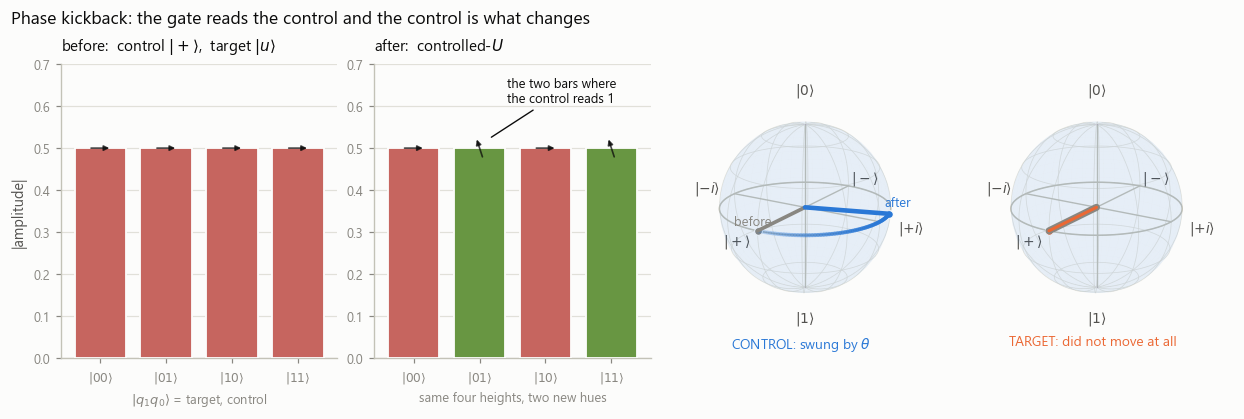

control Bloch  before: [1. 0. 0.]
control Bloch  after : [-0.309017  0.951057  0.      ]
target  Bloch  before: [1. 0. 0.]
target  Bloch  after : [1. 0. 0.]

target unmoved? True
control rotated by   : 0.300000 x 2pi
magnitudes unchanged? True


In [9]:
def reduced_blochs(psi):
    """Bloch vectors of both qubits of a 2-qubit pure state.

    Reshape psi to M[b1, b0] (row = qubit 1, column = qubit 0). Then
    rho_control = M^T M*  and  rho_target = M M^dagger. Both are 2x2, and the
    Bloch vector is r = (tr(rho X), tr(rho Y), tr(rho Z)), all real.
    """
    M = np.asarray(psi).reshape(2, 2)
    rho_c = M.T @ M.conj()
    rho_t = M @ M.conj().T
    def vec(rho):
        return np.array([np.trace(rho @ P).real for P in (X, Y, Z)])
    return vec(rho_c), vec(rho_t)


rc0, rt0 = reduced_blochs(before)
rc1, rt1 = reduced_blochs(after)

fig = plt.figure(figsize=(11.2, 3.7))
gs = fig.add_gridspec(1, 4, width_ratios=[1.0, 1.0, 1.02, 1.02])

ax0 = fig.add_subplot(gs[0, 0])
grid.amp_bars(ax0, before, ylim=0.70)
ax0.set_title("before:  control " + grid.ket("+") + ",  target "
              + grid.ket("u"), loc="left", fontsize=10)
ax0.set_xlabel("$|q_1 q_0\\rangle$ = target, control", fontsize=8.5,
               color=style.MUTED)

ax1 = fig.add_subplot(gs[0, 1])
grid.amp_bars(ax1, after, ylim=0.70)
ax1.set_ylabel("")
ax1.set_title("after:  controlled-$U$", loc="left", fontsize=10)
ax1.set_xlabel("same four heights, two new hues", fontsize=8.5,
               color=style.MUTED)
grid.annotate(ax1, "the two bars where\nthe control reads 1",
              xy=(1.12, 0.52), xytext=(1.42, 0.635), color=style.INK)

# mplot3d leaves a wide margin around the sphere; zoom reclaims it.
arc = np.linspace(0, THETA_P, 60)
axb = fig.add_subplot(gs[0, 2], projection="3d")
bloch.sphere(axb, alpha=0.05)
bloch.path(axb, np.stack([np.cos(arc), np.sin(arc), np.zeros_like(arc)], axis=1),
           color=style.BLUE, lw=2.6)
bloch.vector(axb, rc0, color=style.MUTED, lw=2.4, label="before")
bloch.vector(axb, rc1, color=style.BLUE, lw=3.0, label="after")
axb.set_box_aspect((1, 1, 1), zoom=1.55)
bloch.label(axb, r"CONTROL: swung by $\theta$", y=0.06, color=style.BLUE)

axt = fig.add_subplot(gs[0, 3], projection="3d")
bloch.sphere(axt, alpha=0.05)
bloch.vector(axt, rt0, color=style.MUTED, lw=4.6)
# Both arrows land on the same point, so they get one shared label.
bloch.vector(axt, rt1, color=style.ORANGE, lw=2.0)
axt.set_box_aspect((1, 1, 1), zoom=1.55)
bloch.label(axt, "TARGET: did not move at all", y=0.06, color=style.ORANGE)

fig.suptitle("Phase kickback: the gate reads the control and the control is "
             "what changes", x=0.004, ha="left", fontsize=11.5)
plt.show()

print("control Bloch  before:", np.round(rc0, 6))
print("control Bloch  after :", np.round(rc1, 6))
print("target  Bloch  before:", np.round(rt0, 6))
print("target  Bloch  after :", np.round(rt1, 6))
print("\ntarget unmoved?", np.allclose(rt0, rt1, atol=1e-12))
print("control rotated by   :",
      f"{np.arctan2(rc1[1], rc1[0]) % (2*np.pi) / (2*np.pi):.6f} x 2pi")
print("magnitudes unchanged?", np.allclose(np.abs(before), np.abs(after)))

## Figure 5 — kickback is exact, and it is fragile

Two claims, one figure.

**Left: the kickback is the eigenvalue's argument, exactly.** Sweep $\theta$ over
the full circle, rebuild $U$ each time, and read the phase off the control. The
measured points sit on the diagonal to machine precision. No approximation is
involved anywhere — this is an identity, not a limit.

**Middle and right: it only works on an eigenstate.** Feed the target
$\cos\alpha\,|u_+\rangle + \sin\alpha\,|u_-\rangle$ instead. Now the two branches
of the control get attached to two *different* target states, the output is
**entangled**, and the control is no longer in a pure state at all. Its Bloch
vector shrinks: the equatorial length

$$|r_{xy}| = \big|\cos^2\!\alpha + e^{i(\theta_- - \theta_+)}\sin^2\!\alpha\big|$$

is exactly the **fringe contrast** you would see if you now ran the control
through a Hadamard and swept a phase. At $\alpha = \pi/4$ with our eigenvalues it
drops to $|\cos(\Delta\theta/2)|$, and if the two eigenvalues were opposite
($\Delta\theta = \pi$) it would hit **zero** — the control learns nothing, because
the target has learned everything.

That trade is not a defect of this construction. It is the same conservation law
that runs through the whole subject: **the more the environment knows about which
branch you took, the less those branches can interfere.** The right panel is that
sentence as a picture, and the next section is the same sentence again with the
"environment" being noise.

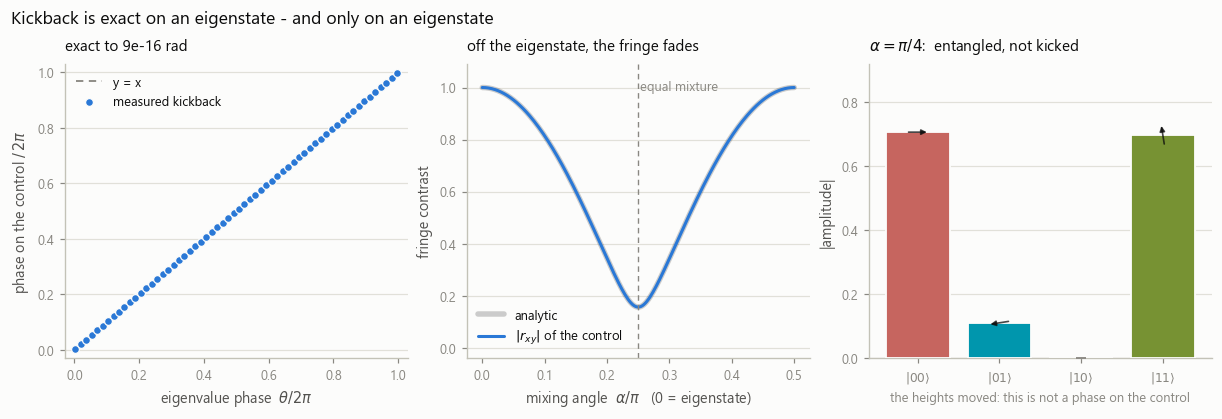

worst |measured - theta| over the sweep: 8.882e-16 rad
contrast at alpha = pi/4 : 0.156434
expected |cos(dtheta/2)| : 0.156434


In [10]:
def kickback_phase(theta_plus, theta_minus=THETA_M, alpha=0.0):
    """Run C-U once and return (kicked phase, control Bloch vector).

    alpha mixes the target away from the eigenstate |u+> toward |u->.
    """
    Uk = V @ np.diag([np.exp(1j * theta_plus),
                      np.exp(1j * theta_minus)]) @ V.conj().T
    target = np.cos(alpha) * PLUS + np.sin(alpha) * MINUS
    psi = controlled(Uk, 0, 1, 2) @ np.kron(target, PLUS)
    rc, _ = reduced_blochs(psi)
    return np.arctan2(rc[1], rc[0]) % (2 * np.pi), rc


thetas = np.linspace(0.02, 2 * np.pi - 0.02, 60)
measured = np.array([kickback_phase(t)[0] for t in thetas])

alphas = np.linspace(0, np.pi / 2, 200)
contrast = np.array([np.linalg.norm(kickback_phase(THETA_P, alpha=a)[1][:2])
                     for a in alphas])
contrast_analytic = np.abs(np.cos(alphas) ** 2
                           + np.exp(1j * (THETA_M - THETA_P)) * np.sin(alphas) ** 2)

fig = plt.figure(figsize=(11.0, 3.7))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])

axa = fig.add_subplot(gs[0, 0])
axa.plot([0, 1], [0, 1], color=style.MUTED, lw=1.2, ls=(0, (4, 3)),
         label="y = x")
axa.scatter(thetas / (2 * np.pi), measured / (2 * np.pi), s=26,
            color=style.BLUE, edgecolor=style.SURFACE, linewidths=0.8,
            zorder=4, label="measured kickback")
axa.set_xlabel(r"eigenvalue phase  $\theta / 2\pi$")
axa.set_ylabel(r"phase on the control $/\,2\pi$")
axa.set_xlim(-0.03, 1.03)
axa.set_ylim(-0.03, 1.03)
axa.legend(loc="upper left")
axa.set_title(f"exact to {np.max(np.abs(measured - thetas)):.0e} rad",
              loc="left", fontsize=10)

axb = fig.add_subplot(gs[0, 1])
axb.plot(alphas / np.pi, contrast_analytic, color=style.INK, lw=3.6, alpha=0.20,
         label="analytic")
axb.plot(alphas / np.pi, contrast, color=style.BLUE, lw=2.0,
         label=r"$|r_{xy}|$ of the control")
axb.axvline(0.25, color=style.MUTED, lw=0.9, ls=(0, (4, 3)))
axb.text(0.253, 1.03, "equal mixture", fontsize=8.5, color=style.MUTED,
         va="top")
axb.set_xlabel(r"mixing angle  $\alpha/\pi$   (0 = eigenstate)")
axb.set_ylabel("fringe contrast")
axb.set_ylim(-0.04, 1.09)
axb.legend(loc="lower left")
axb.set_title("off the eigenstate, the fringe fades", loc="left", fontsize=10)

axc = fig.add_subplot(gs[0, 2])
mixed = controlled(U, 0, 1, 2) @ np.kron(
    (PLUS + MINUS) / np.sqrt(2), PLUS)
grid.amp_bars(axc, mixed, ylim=0.92)
axc.set_title(r"$\alpha = \pi/4$:  entangled, not kicked", loc="left",
              fontsize=10)
axc.set_xlabel("the heights moved: this is not a phase on the control",
               fontsize=8.5, color=style.MUTED)

fig.suptitle("Kickback is exact on an eigenstate - and only on an eigenstate",
             x=0.004, ha="left", fontsize=11.5)
plt.show()

print("worst |measured - theta| over the sweep:",
      f"{np.max(np.abs(measured - thetas)):.3e} rad")
print("contrast at alpha = pi/4 :",
      f"{np.linalg.norm(kickback_phase(THETA_P, alpha=np.pi/4)[1][:2]):.6f}")
print("expected |cos(dtheta/2)| :",
      f"{abs(np.cos((THETA_M - THETA_P) / 2)):.6f}")

## Figure 6 — what kills a fringe: dephasing

Everything above assumed the phase $\varphi$ was a number we control exactly. Real
hardware does not offer that. Stray fields, thermal fluctuations and coupling to
anything at all mean the phase actually applied is $\varphi + \delta$, with
$\delta$ a random kick that differs shot to shot. This is **dephasing**, and it is
the dominant enemy of interference.

We can watch it without any new machinery. Draw $\delta \sim \mathcal{N}(0,\sigma^2)$,
run the interferometer, and average the *probabilities* over the ensemble — not
the amplitudes, because each shot is a separate experiment and it is the counts
that pile up. Then

$$\overline{P(0)} = \overline{\cos^2\!\tfrac{\varphi+\delta}{2}}
= \tfrac12\left(1 + \overline{\cos(\varphi+\delta)}\right)
= \tfrac12\left(1 + e^{-\sigma^2/2}\cos\varphi\right),$$

using the Gaussian identity $\overline{e^{i\delta}} = e^{-\sigma^2/2}$. The fringe
keeps its shape and its centre; what it loses is **contrast**, by a factor
$e^{-\sigma^2/2}$ that decays fast.

The left panel is the waterfall again, now with $\sigma$ as the vertical axis: the
stripes wash out from top to bottom. The middle shows individual fringes
collapsing toward the flat 0.5 line — the classical coin. The right plots the
contrast against the analytic envelope, with Monte-Carlo points from 20000
sampled shots per $\sigma$ on top.

The curves below use Gauss–Hermite quadrature so they are smooth and exactly
reproducible; the dots are honest sampling with the notebook's seeded RNG.

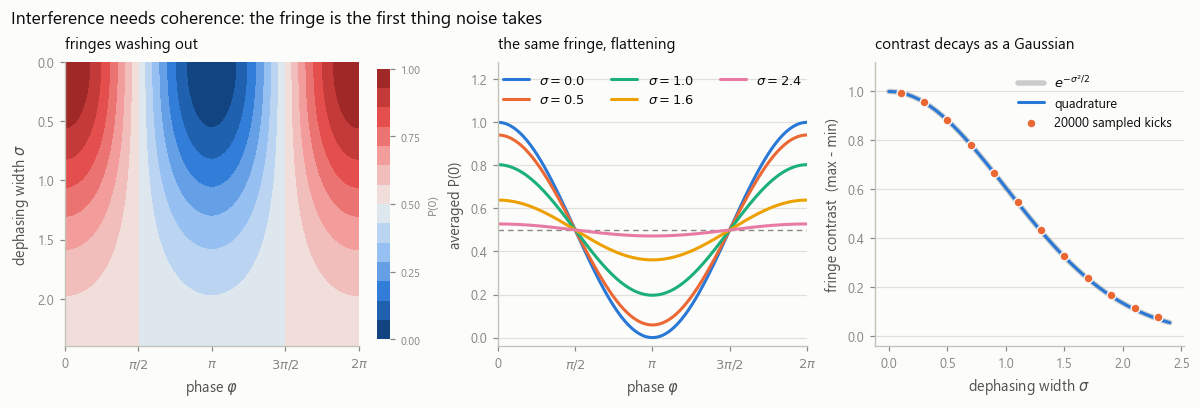

 sigma   contrast   exp(-s^2/2)
  0.00   1.000000      1.000000
  0.50   0.882497      0.882497
  1.00   0.606531      0.606531
  1.50   0.324652      0.324652
  2.00   0.135335      0.135335


In [11]:
# Gauss-Hermite quadrature: integral of exp(-x^2) f(x) dx = sum w_i f(x_i).
# With delta = sqrt(2) sigma x this averages f over N(0, sigma^2) exactly.
GH_X, GH_W = np.polynomial.hermite.hermgauss(64)
GH_W = GH_W / np.sqrt(np.pi)


def dephased_p0(phi, sigma):
    """Ensemble-averaged P(0) under Gaussian phase noise of width sigma."""
    deltas = np.sqrt(2.0) * sigma * GH_X
    p = np.array([probabilities(interferometer(phi + d))[0] for d in deltas])
    return float(GH_W @ p)


def sampled_p0(phi, sigma, shots=20000):
    """The same average, by actually drawing phase kicks."""
    d = rng.normal(0.0, sigma, size=shots)
    return float(np.mean(np.cos((phi + d) / 2) ** 2))


sigmas = np.linspace(0.0, 2.4, 49)
phi_grid = np.linspace(0, 2 * np.pi, 181)
sheet = np.array([[dephased_p0(p, s) for p in phi_grid] for s in sigmas])

fig = plt.figure(figsize=(10.8, 3.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.05, 1.05])

axh = fig.add_subplot(gs[0, 0])
# Banded contours rather than a continuous image: the iso-contrast bands are
# easier to read than a smooth wash, and a banded PNG is a fraction of the bytes
# of a continuous gradient.
im = axh.contourf(phi_grid, sigmas, sheet, levels=np.linspace(0, 1, 15),
                  cmap=style.DIV, vmin=0.0, vmax=1.0)
axh.invert_yaxis()
axh.set_xticks(np.linspace(0, 2 * np.pi, 5))
axh.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axh.set_xlabel(r"phase $\varphi$")
axh.set_ylabel(r"dephasing width $\sigma$")
axh.grid(False)
cb = fig.colorbar(im, ax=axh, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
cb.set_label("P(0)", fontsize=8, color=style.MUTED)
axh.set_title("fringes washing out", loc="left", fontsize=10)

axf = fig.add_subplot(gs[0, 1])
for s, col in zip([0.0, 0.5, 1.0, 1.6, 2.4], style.CAT):
    axf.plot(phi_grid, [dephased_p0(p, s) for p in phi_grid], color=col, lw=2.0,
             label=rf"$\sigma = {s:.1f}$")
axf.axhline(0.5, color=style.MUTED, lw=0.9, ls=(0, (4, 3)), zorder=1)
axf.set_xlim(0, 2 * np.pi)
axf.set_ylim(-0.04, 1.28)
axf.set_xticks(np.linspace(0, 2 * np.pi, 5))
axf.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axf.set_xlabel(r"phase $\varphi$")
axf.set_ylabel("averaged P(0)")
axf.legend(loc="upper center", ncols=3)
axf.set_title("the same fringe, flattening", loc="left", fontsize=10)

axc = fig.add_subplot(gs[0, 2])
contrast_num = sheet.max(axis=1) - sheet.min(axis=1)
axc.plot(sigmas, np.exp(-sigmas ** 2 / 2), color=style.INK, lw=3.6, alpha=0.20,
         label=r"$e^{-\sigma^2/2}$")
axc.plot(sigmas, contrast_num, color=style.BLUE, lw=2.0, label="quadrature")
mc_sigmas = np.linspace(0.1, 2.3, 12)
mc = [max(sampled_p0(p, s) for p in phi_grid[::6])
      - min(sampled_p0(p, s) for p in phi_grid[::6]) for s in mc_sigmas]
axc.scatter(mc_sigmas, mc, s=34, color=style.ORANGE, edgecolor=style.SURFACE,
            linewidths=0.9, zorder=5, label="20000 sampled kicks")
axc.set_xlabel(r"dephasing width $\sigma$")
axc.set_ylabel("fringe contrast  (max - min)")
axc.set_ylim(-0.04, 1.12)
axc.legend(loc="upper right")
axc.set_title("contrast decays as a Gaussian", loc="left", fontsize=10)

fig.suptitle("Interference needs coherence: the fringe is the first thing noise "
             "takes", x=0.004, ha="left", fontsize=11.5)
plt.show()

print(f"{'sigma':>6} {'contrast':>10} {'exp(-s^2/2)':>13}")
for s in [0.0, 0.5, 1.0, 1.5, 2.0]:
    c = dephased_p0(0.0, s) - dephased_p0(np.pi, s)
    print(f"{s:6.2f} {c:10.6f} {np.exp(-s**2/2):13.6f}")

## Honest limits

**Interference is not a picture you can keep drawing.** Figure 1 works because
there are two paths. Figure 3 needed eight arrows and already had to be shown as
a heatmap rather than as arrows. A 20-qubit circuit has $2^{20}$ paths to each
outcome; there is no Argand diagram for that, and no amount of clever plotting
will produce one. Past about five qubits the amplitude bars become a texture, not
a reading — A07 confronts that wall directly.

**Coherence is a resource with a clock on it.** Figure 6 modelled dephasing as an
ensemble average over random phase kicks, which is *correct* but is not the full
story: it treats the noise as classical randomness we happen not to know. The
honest object is a **density matrix**, where dephasing shrinks the off-diagonal
elements — literally the terms that carry interference — and the contrast
$e^{-\sigma^2/2}$ becomes the $T_2$ decay of a real device. A12 builds that
machinery, and B20 measures a fringe collapsing on a simulated backend. What our
model does get exactly right is the punchline: **contrast, not centre**. Dephasing
does not bias the answer, it erases the signal.

**Amplitude damping is a different animal.** We only randomised the *phase*. A
qubit that actually decays to $|0\rangle$ loses the fringe too, but it also moves
the mean — a distinction our ensemble-of-phases model cannot express at all.

**Kickback needs an eigenstate, and you rarely have one.** Figure 5's middle panel
is the caveat that matters for real algorithms. In phase estimation you generally
cannot prepare $|u\rangle$; you prepare something that *overlaps* it, and the
algorithm returns the eigenphase of whichever eigenvector it collapsed onto, with
probability equal to the overlap. That is a feature (it is how Shor works) but it
means "the answer" is a distribution, not a number. A11 and B24 deal with it.

**The bars hide entanglement.** In Figure 4 the before and after states have
identical bar heights, and both happen to be product states. In Figure 5's third
panel they are four bars of unequal height and nothing more — nothing in the
picture announces that *that* state is entangled while the other two are not.
Amplitude
bars are a complete description of a pure state and still say nothing at a glance
about correlation between qubits — you have to compute something (a Schmidt rank,
a reduced state) to find out. A06 built the test; A12 generalises it.

**Everything here was noiseless and exact.** No shot noise, no gate error, no
measurement error. The fringes in Figures 2 and 3 are analytic curves that happen
to have been computed numerically. Real fringes are drawn from finite samples and
wobble; B16 and B20 show what that costs.

## Checkpoint

In [12]:
# 1. The sum over paths is the matrix product, and is cos^2(phi/2).
for phi in rng.uniform(0, 2 * np.pi, 200):
    summed = np.array([path_amplitudes(k, phi).sum() for k in (0, 1)])
    assert np.allclose(summed, interferometer(phi), atol=1e-14)
    assert np.isclose(abs(summed[0]) ** 2, np.cos(phi / 2) ** 2, atol=1e-14)
    assert np.isclose(abs(summed[1]) ** 2, np.sin(phi / 2) ** 2, atol=1e-14)

# 2. Perfect destructive interference is EXACTLY zero, not merely small.
assert abs(path_amplitudes(1, 0.0).sum()) < 1e-16
assert abs(path_amplitudes(0, np.pi).sum()) < 1e-15

# 3. The interference term accounts for the whole departure from classical.
for phi in rng.uniform(0, 2 * np.pi, 100):
    a = path_amplitudes(0, phi)
    classical = np.sum(np.abs(a) ** 2)
    cross = 2 * np.real(np.conj(a[0]) * a[1])
    assert np.isclose(abs(a.sum()) ** 2, classical + cross)
    assert np.isclose(classical, 0.5)          # the classical part never moves

# 4. A relative phase is invisible until it is interfered.
assert np.allclose(probabilities(PLUS), probabilities(MINUS))
assert not np.allclose(PLUS, MINUS)
assert np.allclose(probabilities(H @ PLUS), [1, 0])
assert np.allclose(probabilities(H @ MINUS), [0, 1])

# 5. A GLOBAL phase is invisible no matter what we do to it.
for phi in rng.uniform(0, 2 * np.pi, 50):
    g = np.exp(1j * phi)
    assert np.allclose(probabilities(H @ (g * PLUS)), probabilities(H @ PLUS))

# 6. The 8-path waterfall: unitary evolution, so every row is a distribution.
assert np.allclose(water.sum(axis=1), 1.0)
assert np.all(water >= -1e-15)
# ...and the |000> column is the N-slit formula to machine precision.
assert np.max(np.abs(water[:, 0] - analytic)) < 1e-12

# 7. THE headline: the phase kicked onto the control equals the eigenvalue's
#    argument, to 1e-12.
assert np.isclose(kicked, THETA_P, atol=1e-12)
for theta in rng.uniform(0, 2 * np.pi, 100):
    got, _ = kickback_phase(theta)
    assert np.isclose((got - theta + np.pi) % (2 * np.pi) - np.pi, 0.0,
                      atol=1e-12)

# 8. Kickback leaves the target's reduced state exactly untouched, and leaves
#    every magnitude in the register untouched.
rc_b, rt_b = reduced_blochs(before)
rc_a, rt_a = reduced_blochs(after)
assert np.allclose(rt_b, rt_a, atol=1e-12)
assert np.allclose(np.abs(before), np.abs(after), atol=1e-14)
assert np.isclose(np.linalg.norm(rc_a), 1.0, atol=1e-12)     # still pure
assert not np.allclose(rc_b, rc_a)                           # but it moved

# 9. Off the eigenstate, the control's contrast is the analytic overlap.
for a in rng.uniform(0, np.pi / 2, 50):
    r = kickback_phase(THETA_P, alpha=a)[1]
    want = abs(np.cos(a) ** 2
               + np.exp(1j * (THETA_M - THETA_P)) * np.sin(a) ** 2)
    assert np.isclose(np.linalg.norm(r[:2]), want, atol=1e-12)

# 10. Dephasing: contrast decays exactly as exp(-sigma^2/2), and the fringe
#     centre never moves.
for s in [0.0, 0.3, 0.7, 1.2, 2.0]:
    c = dephased_p0(0.0, s) - dephased_p0(np.pi, s)
    assert np.isclose(c, np.exp(-s ** 2 / 2), atol=1e-10)
    assert np.isclose(dephased_p0(np.pi / 2, s), 0.5, atol=1e-10)

# 11. Everything we built is unitary.
for M in (H, U, CU, H3, phase_ramp(0.9), controlled(U, 0, 1, 2)):
    d = M.shape[0]
    assert np.allclose(M.conj().T @ M, np.eye(d), atol=1e-12)

print("A08 checkpoint passed.")

A08 checkpoint passed.


---

**Next:** [A09 — Deutsch–Jozsa and Bernstein–Vazirani](A09_Deutsch_Jozsa.ipynb).
We now have the two ingredients of every quantum algorithm: a way to make paths
cancel, and a way to write an answer onto a qubit nothing appeared to touch. A09
spends exactly one oracle query with them, and gets an answer no classical
algorithm can get in fewer than two.